In [1]:
import jax
import jax.numpy as jnp
import jax
import optax
import numpy as np
import neuralgcm
import xarray
import copy
import logging
import sys
import h5py
import pickle
from datetime import datetime, timedelta

In [1]:
Nens = 1
#Nens = 30 # number of ensemble members
# ndays = 14 # length of full forecast optimization window in days
ndays = 8 # length of full forecast optimization window in days
niters = 6 # number of optimization iterations
#niters = 100 # number of optimization iterations
vvars = ['temperature','geopotential','u_component_of_wind','v_component_of_wind']
learn_rate = 1e-5
#sdate = '2011-04-08T00' # starting date (optimize the initial condition at this time)
#sdate = '2021-03-30T00'; exp_name = 'march2021'
sdate = '2014-03-15T00'; exp_name = 'march2014'
# sdate = '2014-03-15T00'; exp_name = 'march2014_long'

#
# choose a model:
#
# model_name = 'tl63_stochastic_mini.pkl'
model_name = 'neural_gcm_dynamic_forcing_deterministic_2_8_deg.pkl'
#model_name = 'neural_gcm_dynamic_forcing_deterministic_1_4_deg.pkl'
#model_name = 'neural_gcm_dynamic_forcing_stochastic_1_4_deg.pkl'

# paths to data
path_input = '/glade/work/hakim/data/ai-models/neuralgcm/input/'+exp_name+'/'
# path_output =  '/glade/work/hakim/data/ai-models/neuralgcm/output/'
path_output = '/glade/campaign/univ/uwas0152/neuralGCM_data/optimizations/'
path_model = '/glade/work/hakim/data/ai-models/neuralgcm/models/'

In [2]:
def add_one_day(date_str):
    # Parse the input string into a datetime object
    date_format = '%Y-%m-%dT%H'
    date_obj = datetime.strptime(date_str, date_format)

    # Add one day to the date
    new_date_obj = date_obj + timedelta(days=1)

    # Format the new date back into a string
    new_date_str = new_date_obj.strftime(date_format)

    return new_date_str

# save forecast dictionary to h5py file
def save_h5(fdict,ofile):
    f = h5py.File(ofile,'w')
    for grp_name in fdict:
        print(grp_name)
        dset = f.create_dataset(grp_name, data = fdict[grp_name])
    f.close()
    return

# save optimal initial condition to a nc file, same as control input
def save_xr(model,ds_h,input_decoded,ofile):

    # add time dimension to the optimal arrays
    ovars = ['geopotential', 'specific_cloud_ice_water_content', 'specific_cloud_liquid_water_content', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind']
    # new dimensions; time in first dimension
    new_dims = tuple([1])+input_decoded['geopotential'].shape
    # dictionary with new arrays
    new_arrs = {}
    for v in ovars:
        tmp = np.zeros(new_dims)
        tmp[0,:] = input_decoded[v]
        new_arrs[v] = tmp

    # create a template from the original, and put my data in it
    ds_new = ds_h.copy(data={
        'geopotential': new_arrs['geopotential'],
        'sea_surface_temperature': ds_h['sea_surface_temperature'],
        'sea_ice_cover': ds_h['sea_ice_cover'],
        'specific_cloud_ice_water_content': new_arrs['specific_cloud_ice_water_content'],
        'specific_humidity': new_arrs['specific_humidity'],
        'v_component_of_wind': new_arrs['v_component_of_wind'],
        'temperature': new_arrs['temperature'],
        'specific_cloud_liquid_water_content': new_arrs['specific_cloud_liquid_water_content'],
        'u_component_of_wind': new_arrs['u_component_of_wind']
    })

    # save the dataset
    ds_new.to_netcdf(ofile)

    return

def get_logger():
    logger = logging.getLogger()
    logger.setLevel(logging.INFO)
    handler = logging.StreamHandler(sys.stdout)
    handler.setLevel(logging.INFO)
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    handler.setFormatter(formatter)
    logger.addHandler(handler)
    return logger

@jax.jit
def forecast_partial(model,input_encoded,forcings):
    steps = 2 # number of days for inner loop: must match compute_loss_traj
    dt = np.timedelta64(24, 'h')  # save outputs once per day
    output_encoded,output_decoded = model.unroll(input_encoded,forcings,steps=steps,timedelta=dt)
    return output_encoded,output_decoded

@jax.jit
def compute_loss_traj(model,inputs_state,inputs,all_forcings,rng,verif,max_norm):
    substep = 2 # number of days for inner loop: must match forecast_partial!
    steps = verif[list(verif.keys())[0]].shape[0] # total number of days
    # make sure we have an integer multiple of the substep
    assert(np.allclose(steps/substep,int(steps/substep)))
    nsubsteps = int(steps/substep)
    # prep for calling the forecast
    f_encoded = copy.copy(inputs)
    f_encoded.state = inputs_state
    # selected variables for computing the loss are in the verification dictionary
    svars = verif.keys()
    # outer loop
    sind = 0
    eind = 0
    J = 0.
    for s in range(nsubsteps):
        f_encoded,f_decoded = jax.checkpoint(forecast_partial)(model,f_encoded,all_forcings)
        eind = eind+substep
        # accumulate loss
        for k in svars:
            # global:
            J = J + np.mean(((verif[k][sind:eind,14:,:,:] - f_decoded[k][:,14:,:,:])/max_norm[k][14:])**2)
            # NH
            #J = J + jnp.nanmean(((verif[k][sind:eind,14:,:,31:63] - f_decoded[k][:,14:,:,31:63])/max_norm[v][14:])**2)
            # PNW (remember lat and lon are reversed in this model: (lev,lon,lat)!)
            #J = J + jnp.nanmean(((verif[k][sind:eind,14:,82:89,47:53] - f_decoded[k][:,14:,82:89,47:53])/max_norm[v][14:])**2)
        sind = sind+substep
    return J

In [4]:
# initialize logger
logger = get_logger()

logger.info('reading model checkpoint...')
with open(path_model+model_name,'rb') as handle:
    ckpt = pickle.load(handle)
model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)

logger.info('reading heatwave initial confition...')
ds_h_all = xarray.open_dataset(path_input+sdate+'.nc')
all_forcings = model.forcings_from_xarray(ds_h_all)
ds_h = ds_h_all.isel(time=0)
inputs_h, forcings_h = model.data_from_xarray(ds_h)

logger.info('reading verification data...')
vfpath = path_input
verif_traj = {}
old_date = sdate
for d in range(ndays):
    new_date = add_one_day(old_date)
    old_date = new_date
    infile = vfpath+new_date+'.nc'
    print(d,infile)
    ds_v = xarray.open_dataset(infile)
    print(ds_v['time'])
    if d == 0:
        nlevs = ds_v['temperature'].shape[1]
        nlats = ds_v['temperature'].shape[3]
        nlons = ds_v['temperature'].shape[2]
        for v in vvars:
            verif_traj[v] = np.zeros([ndays,nlevs,nlons,nlats])
    for v in vvars:
        verif_traj[v][d,:,:,:] = ds_v[v]
    ds_v.close()

# compute normalizing factors for each variable and each level, using the value value at the first time
max_norm = {}
for v in vvars:
    # GH 11/17/2024: I commented this out since it is set in the block above; not tested!
    #verif_traj[v][d,:,:,:] = ds_v[v]
    std_values = verif_traj[v][0,:,:,:].std(axis=(1,2), keepdims=True)
    max_norm[v] = std_values

2026-02-19 17:29:08,426 - INFO - reading model checkpoint...
2026-02-19 17:29:08,426 - INFO - reading model checkpoint...
2026-02-19 17:29:08,585 - INFO - reading heatwave initial confition...
2026-02-19 17:29:08,585 - INFO - reading heatwave initial confition...
2026-02-19 17:29:08,607 - INFO - reading verification data...
2026-02-19 17:29:08,607 - INFO - reading verification data...
0 /glade/work/hakim/data/ai-models/neuralgcm/input/march2014/2014-03-16T00.nc
<xarray.DataArray 'time' (time: 1)> Size: 8B
array(['2014-03-16T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 8B 2014-03-16
1 /glade/work/hakim/data/ai-models/neuralgcm/input/march2014/2014-03-17T00.nc
<xarray.DataArray 'time' (time: 1)> Size: 8B
array(['2014-03-17T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 8B 2014-03-17
2 /glade/work/hakim/data/ai-models/neuralgcm/input/march2014/2014-03-18T00.nc
<xarray.DataArray 'time' (time: 1)

In [ ]:
#---------------------------------------------------
#---- START MAIN: optimize ensemble members one at a time
#---------------------------------------------------
for emem in range(Nens):
    logger.info('encoding initial condition for member'+str(emem))
    input_encoded = model.encode(inputs_h,forcings_h,jax.random.key(emem))

    # initialize
    optimizer = optax.adam(learn_rate)  # dry variables only
    opt_model = model
    opt_state = optimizer.init(input_encoded.state)
    params = input_encoded.state
    lsave_heatwave = []
    loss_min = 1e19
    #-----------------------------------------
    # trajectory optimization
    #-----------------------------------------
    for i in range(niters):
        loss, grads = jax.value_and_grad(compute_loss_traj,argnums=1)(opt_model,params,input_encoded,all_forcings,jax.random.key(emem),verif_traj,max_norm)
        lsave_heatwave.append(loss)
        # save the best iteration
        if loss < loss_min:
            logger.info('new best optimal...')
            loss_min = loss
            params_best = copy.copy(params)
        # zero out moisture variable gradients
        for k in grads.asdict()['tracers'].keys():
            grads.asdict()['tracers'][k] = 0.*grads.asdict()['tracers'][k]
        # zero out surface pressure gradients
        #grads.log_surface_pressure = 0.*grads.log_surface_pressure
        # update state
        updates, opt_state = optimizer.update(grads,opt_state,params)
        params = optax.apply_updates(params, updates)
        logger.info(f'{i=}, {loss=}')

    #-----------------------------------------
    # make control and optimal forecasts
    #-----------------------------------------
    dt = np.timedelta64(24, 'h')  # save outputs once per day

    logger.info('control forecast...')
    encoded_state_c,long_outputs_c = model.unroll(input_encoded,all_forcings,steps=ndays,timedelta=dt)
    # optimal forecast
    fix_inputs = copy.copy(input_encoded)
    fix_inputs.state = params_best
    logger.info('optimal forecast...')
    encoded_state_o,long_outputs_o = model.unroll(fix_inputs,all_forcings,steps=ndays,timedelta=dt)

    logger.info('saving files to disk...')
    flabel = '_emem_'+str(emem)
    #flabel = '_emem_PNW_'+str(emem)
    #flabel = '_emem_subsetNH_'+str(emem)
    # save control forecast, optimal forecast, and optimal initial condition
    save_h5(long_outputs_c,path_output+sdate+'_control_forecast_'+str(ndays)+'d_'+str(niters)+'it'+flabel+'.h5')
    save_h5(long_outputs_o,path_output+sdate+'_optimal_forecast_'+str(ndays)+'d_'+str(niters)+'it'+flabel+'.h5')
    # old h5 file saves for ICs doesn't work for reading them to make new forecasts
    #save_h5(model.decode(fix_inputs,forcings_h),path_output+sdate+'_optimal_inputs_'+str(ndays)+'d_'+str(niters)+'it'+flabel+'.h5')
    #save_h5(model.decode(input_encoded,forcings_h),path_output+sdate+'_control_inputs_'+str(ndays)+'d_'+str(niters)+'it'+flabel+'.h5')
    # use xarray and save nc files for future forecast experiments
    save_xr(model,ds_h_all,model.decode(fix_inputs,forcings_h),path_output+sdate+'_optimal_inputs_'+str(ndays)+'d_'+str(niters)+'it'+flabel+'.nc')
    save_xr(model,ds_h_all,model.decode(input_encoded,forcings_h),path_output+sdate+'_control_inputs_'+str(ndays)+'d_'+str(niters)+'it'+flabel+'.nc')
    # save loss too
    with open(path_output+sdate+'_loss_'+str(ndays)+'d_'+str(niters)+'it'+flabel+'.txt', 'w') as f:
        for l in lsave_heatwave:
            f.write(f"{l}\n")

print("Finished")

2026-02-19 17:29:48,285 - INFO - encoding initial condition for member0
2026-02-19 17:29:48,285 - INFO - encoding initial condition for member0
2026-02-19 17:29:48,579 - INFO - [NGCM] Initializing ZerosRandomField
2026-02-19 17:29:48,579 - INFO - [NGCM] Initializing ZerosRandomField
2026-02-19 17:29:49,409 - INFO - [NGCM] Initializing NoRandomField
2026-02-19 17:29:49,409 - INFO - [NGCM] Initializing NoRandomField
2026-02-19 17:29:49,635 - INFO - [NGCM] Initializing ZerosRandomField
2026-02-19 17:29:49,635 - INFO - [NGCM] Initializing ZerosRandomField
2026-02-19 17:29:49,841 - INFO - [NGCM] Initializing ZerosRandomField
2026-02-19 17:29:49,841 - INFO - [NGCM] Initializing ZerosRandomField
2026-02-19 17:29:49,857 - INFO - [NGCM] Initializing DynamicDataForcing with dt_tolerance='1 year'
2026-02-19 17:29:49,857 - INFO - [NGCM] Initializing DynamicDataForcing with dt_tolerance='1 year'
2026-02-19 17:29:49,917 - INFO - [NGCM] Initializing ZerosRandomField
2026-02-19 17:29:49,917 - INFO - [

In [9]:
import xarray as xr
control_input = xr.open_dataset('/glade/campaign/univ/uwas0152/neuralGCM_data/optimizations/2014-03-15T00_control_inputs_2d_10it_emem_0.nc')
optimal_input = xr.open_dataset('/glade/campaign/univ/uwas0152/neuralGCM_data/optimizations/2014-03-15T00_optimal_inputs_2d_10it_emem_0.nc')

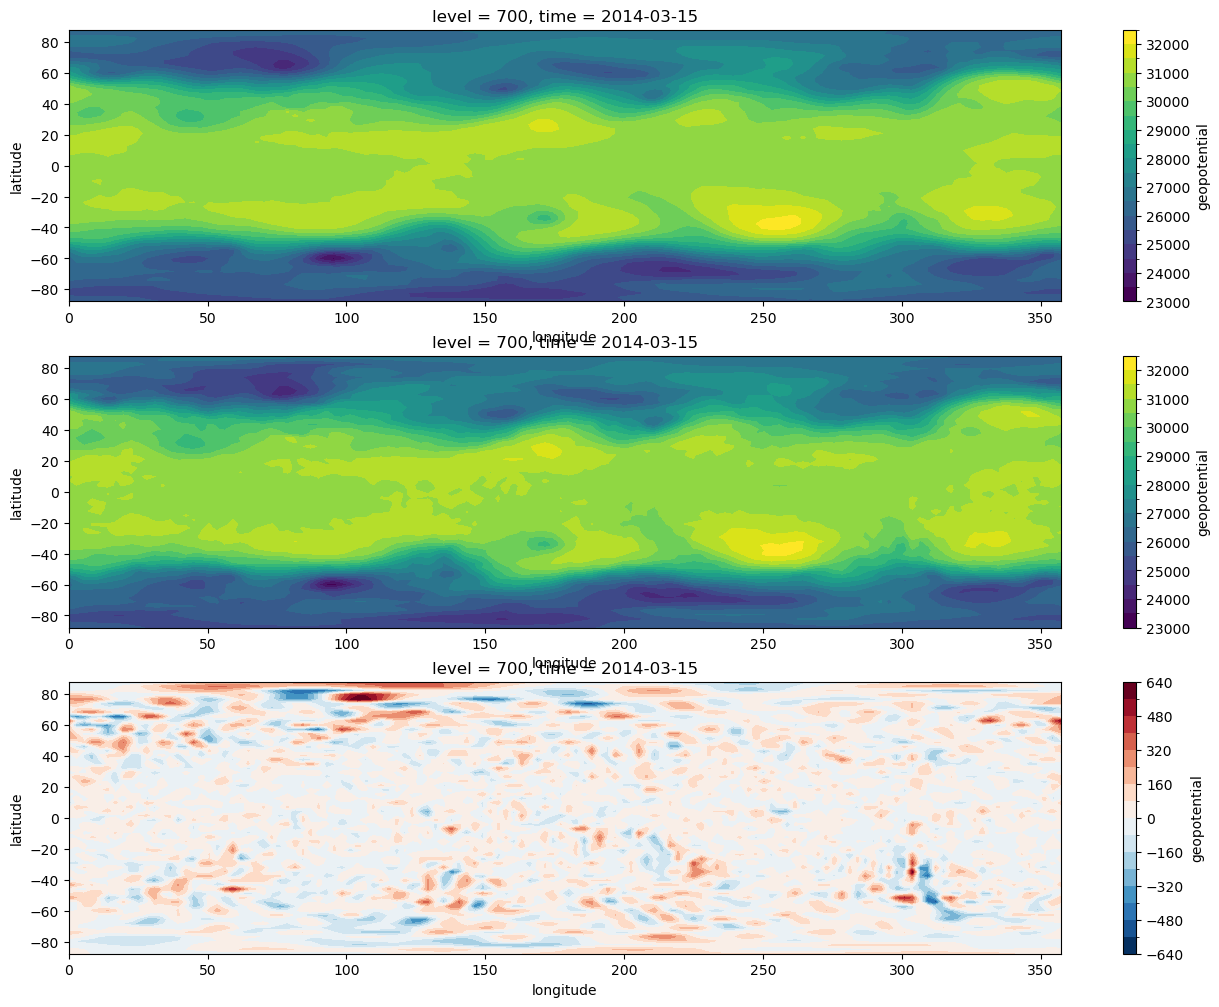

In [10]:
import matplotlib.pyplot as plt
[fig, ax] = plt.subplots(3, 1, figsize=(16, 12))
control_input['geopotential'].sel(level=700).isel(time=0).plot.contourf(ax=ax[0], x='longitude', y='latitude', levels=21)
optimal_input['geopotential'].sel(level=700).isel(time=0).plot.contourf(ax=ax[1], x='longitude', y='latitude', levels=21)
(
    optimal_input['geopotential'].sel(level=700).isel(time=0)
    - control_input['geopotential'].sel(level=700).isel(time=0)
).plot.contourf(ax=ax[2], x='longitude', y='latitude', levels=21)

In [28]:
print(vfpath+new_date+'.nc')

/glade/work/hakim/data/ai-models/neuralgcm/input/march2014/2014-03-17T00.nc


In [29]:
indata = xr.open_dataset("/glade/work/hakim/data/ai-models/neuralgcm/input/march2014/2014-03-17T00.nc")

In [30]:
indata

<xarray.Dataset> Size: 9MB
Dimensions:                              (level: 37, time: 1, longitude: 128,
                                          latitude: 64)
Coordinates:
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * time                                 (time) datetime64[ns] 8B 2014-03-17
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
Data variables:
    geopotential                         (time, level, longitude, latitude) float32 1MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 1MB ...
    temperature                          (time, level, longitude, latitude) float32 1MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 1MB ...
    v_component_of_wind                  (time, level, longitude, latitude) float32 1MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 1MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 1MB ...
    sea_ice_cover                        (time, longitude, latitude) float32 33kB ...
    sea_surface_temperature              (time, longitude, latitude) float32 33kB ...

In [31]:
ds_h_all

<xarray.Dataset> Size: 9MB
Dimensions:                              (level: 37, time: 1, longitude: 128,
                                          latitude: 64)
Coordinates:
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * time                                 (time) datetime64[ns] 8B 2014-03-15
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
Data variables:
    geopotential                         (time, level, longitude, latitude) float32 1MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 1MB ...
    temperature                          (time, level, longitude, latitude) float32 1MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 1MB ...
    v_component_of_wind                  (time, level, longitude, latitude) float32 1MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 1MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 1MB ...
    sea_ice_cover                        (time, longitude, latitude) float32 33kB ...
    sea_surface_temperature              (time, longitude, latitude) float32 33kB ...